In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q torchvision

In [3]:
import os, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
 
import cv2
import torchvision.models as models
import torchvision.transforms as transforms
 
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [14]:
import glob
 
matches = glob.glob(
    "/kaggle/input/**/*demographic*", recursive=True
) + glob.glob(
    "/kaggle/input/**/*questionnari*", recursive=True
)
print("Demographic file(s) found:")
for m in matches:
    print(" ", m)
 
DEMO_PATH  = matches[0]   # takes first match — adjust index if wrong
VIDEO_ROOT = "/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Advertisement Categories"
 
print("\nVideo root exists:", os.path.exists(VIDEO_ROOT))

Demographic file(s) found:
  /kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Participant Data/Participant_demographic_questionnaries.xlsx
  /kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Participant Data/Participant_demographic_questionnaries.xlsx

Video root exists: True


In [15]:
df = pd.read_excel(DEMO_PATH, sheet_name="Sheet1")
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())
 
for col in ["SIGNALID", "SUBID", "GENDER", "AGE"]:
    if col in df.columns:
        df[col] = df[col].ffill()
 
df["label"] = (
    df["INTERESTED IN"]
    .astype(str).str.strip().str.lower()
    .map({"yes": 1, "no": 0})
)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
 
# Normalise SUBID and ADDNO to integers for path matching
df["SUBID"]  = pd.to_numeric(df["SUBID"],  errors="coerce").fillna(0).astype(int)
df["ADDNO"]  = pd.to_numeric(df["ADDNO"],  errors="coerce").fillna(0).astype(int)
 
print("\nShape:", df.shape)
print("Label balance:\n", df["label"].value_counts())

Columns: ['SIGNALID', 'SUBID', 'GENDER', 'AGE', 'ADDNO', 'TIME', 'P/N (1-5)', 'EMOTIONS (%)', 'INTERESTED IN']

Shape: (670, 10)
Label balance:
 label
1    455
0    215
Name: count, dtype: int64


In [16]:
EMOTION_CODES = ["J", "SU", "F", "D", "SA", "A"]
# emotion folder names seen in the dataset
EMOTION_FOLDER_MAP = {
    "J": "J", "SU": "SU", "F": "F",
    "D": "D", "SA": "SA", "A": "A", "N": "N"
}
 
def parse_emotions(s):
    result = {c: 0.0 for c in EMOTION_CODES}
    if not isinstance(s, str) or s.strip() in ("-", ""):
        return result
    tokens = re.findall(r"([A-Z]+)[%\-](\d*\.?\d+)", s)
    for code, pct in tokens:
        if code in result and pct:
            result[code] = min(float(pct) / 100.0, 1.0)
    return result
 
emo_parsed = df["EMOTIONS (%)"].apply(parse_emotions)
for code in EMOTION_CODES:
    df[f"emo_{code}"] = emo_parsed.apply(lambda d: d[code])
 
print("Emotion columns added.")

Emotion columns added.


In [17]:
emo_cols = [f"emo_{c}" for c in EMOTION_CODES]
 
df["gender_bin"] = (
    df["GENDER"].astype(str).str.strip().str.lower() == "male"
).astype(float)
 
df["age"] = pd.to_numeric(df["AGE"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())
 
df["age_group"] = pd.cut(
    df["age"], bins=[0, 18, 30, 50, 120], labels=[0, 1, 2, 3]
).astype(float).fillna(1.0)
 
time_col = [c for c in df.columns if "TIME" in c.upper()]
if time_col:
    df["time_log"] = np.log1p(
        pd.to_numeric(df[time_col[0]], errors="coerce").fillna(0).abs()
    )
else:
    df["time_log"] = 0.0
 
df["ad_code"] = df["ADDNO"].astype(float)
 
pn_col = [c for c in df.columns if "P/N" in c.upper() or "PN" in c.upper()]
if pn_col:
    df["pn_rating"] = pd.to_numeric(df[pn_col[0]], errors="coerce").fillna(3.0)
else:
    df["pn_rating"] = 3.0
 
df["emo_max"]     = df[emo_cols].max(axis=1)
df["emo_mean"]    = df[emo_cols].mean(axis=1)
df["emo_sum"]     = df[emo_cols].sum(axis=1)
df["emo_count"]   = (df[emo_cols] > 0).sum(axis=1).astype(float)
df["emo_std"]     = df[emo_cols].std(axis=1).fillna(0)
df["emo_entropy"] = df[emo_cols].apply(
    lambda r: -np.sum([p * np.log(p + 1e-9) for p in r if p > 0]), axis=1
)
df["dom_emo_idx"]       = df[emo_cols].values.argmax(axis=1).astype(float)
df["dom_emo_intensity"] = df["emo_max"]
 
for i, code in enumerate(EMOTION_CODES):
    df[f"dom_{code}"] = (df["dom_emo_idx"] == i).astype(float)
 
df["pos_emo_sum"]   = df[["emo_J","emo_SU"]].sum(axis=1)
df["neg_emo_sum"]   = df[["emo_F","emo_D","emo_SA","emo_A"]].sum(axis=1)
df["pos_neg_ratio"] = df["pos_emo_sum"] / (df["neg_emo_sum"] + 1e-9)
df["joy_x_surprise"]  = df["emo_J"] * df["emo_SU"]
df["strong_positive"] = ((df["emo_J"] > 0.5) | (df["emo_SU"] > 0.5)).astype(float)
df["neg_dominant"]    = (df["neg_emo_sum"] > df["pos_emo_sum"]).astype(float)
df["pn_x_joy"]        = df["pn_rating"] * df["emo_J"]
df["pn_x_surprise"]   = df["pn_rating"] * df["emo_SU"]
 
FEATURE_COLS = (
    ["gender_bin", "age", "age_group", "time_log", "ad_code", "pn_rating"]
    + emo_cols
    + [f"dom_{c}" for c in EMOTION_CODES]
    + ["emo_max","emo_mean","emo_sum","emo_count","emo_std","emo_entropy"]
    + ["dom_emo_idx","dom_emo_intensity"]
    + ["pos_emo_sum","neg_emo_sum","pos_neg_ratio",
       "joy_x_surprise","strong_positive","neg_dominant",
       "pn_x_joy","pn_x_surprise"]
)
 
print(f"Total demographic features: {len(FEATURE_COLS)}")
print(f"Dataset rows: {len(df)}")
 

Total demographic features: 34
Dataset rows: 670


In [18]:
def find_video_for_row(subid, addno, video_root):
    """
    Walk all category folders looking for
    .../SubjectID/A{addno:02d}/{emotion}/*.mp4
    Returns first mp4 found or None.
    """
    subid_str = str(int(subid))
    add_str   = f"A{int(addno):02d}"
 
    for category in os.listdir(video_root):
        cat_path = os.path.join(video_root, category)
        if not os.path.isdir(cat_path):
            continue
        sub_path = os.path.join(cat_path, subid_str)
        if not os.path.isdir(sub_path):
            continue
        add_path = os.path.join(sub_path, add_str)
        if not os.path.isdir(add_path):
            continue
        # look inside emotion subfolders
        for emo_folder in os.listdir(add_path):
            emo_path = os.path.join(add_path, emo_folder)
            if not os.path.isdir(emo_path):
                continue
            for f in os.listdir(emo_path):
                if f.endswith(".mp4"):
                    return os.path.join(emo_path, f)
    return None
 
print("Scanning for videos ... (may take ~30 seconds)")
df["video_path"] = df.apply(
    lambda r: find_video_for_row(r["SUBID"], r["ADDNO"], VIDEO_ROOT), axis=1
)
 
total     = len(df)
has_video = df["video_path"].notna().sum()
print(f"Rows with video found : {has_video} / {total}")
print(f"Rows without video    : {total - has_video}")
 
# Keep only rows that have a video
df_video = df[df["video_path"].notna()].reset_index(drop=True)
print(f"\nWorking dataset size  : {len(df_video)}")
print(f"Label balance:\n{df_video['label'].value_counts()}")

Scanning for videos ... (may take ~30 seconds)
Rows with video found : 666 / 670
Rows without video    : 4

Working dataset size  : 666
Label balance:
label
1    453
0    213
Name: count, dtype: int64


In [12]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for d in dirs:
        if "advertisement" in d.lower() or "categor" in d.lower():
            print(os.path.join(root, d))

/kaggle/input/datasets/alicia2uu/neurobiosense-dataset/NeuroBioSense Dataset/NeuroBioSense/Advertisement Categories


In [19]:
IMG_SIZE   = 224
NUM_FRAMES = 8      # frames sampled per video clip
 
video_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std =[0.229, 0.224, 0.225]
    ),
])
 
def extract_frames(video_path, num_frames=NUM_FRAMES):
    """
    Sample `num_frames` evenly spaced frames from a video.
    Returns tensor of shape (num_frames, 3, 224, 224).
    Returns zeros if video cannot be read.
    """
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
 
    if total <= 0:
        cap.release()
        return torch.zeros(num_frames, 3, IMG_SIZE, IMG_SIZE)
 
    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(video_transform(frame))
        else:
            frames.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
    cap.release()
    return torch.stack(frames)   # (num_frames, 3, 224, 224)
 
# Quick test
test_path = df_video["video_path"].iloc[0]
test_frames = extract_frames(test_path)
print(f"Test frame tensor shape: {test_frames.shape}")
print("Frame extraction working ✓")

Test frame tensor shape: torch.Size([8, 3, 224, 224])
Frame extraction working ✓


In [20]:
mobilenet_backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
mobilenet_backbone.classifier = nn.Identity()
mobilenet_backbone = mobilenet_backbone.to(DEVICE)
mobilenet_backbone.eval()
 
@torch.no_grad()
def get_video_embedding(video_path):
    """
    Extract NUM_FRAMES frames → pass each through MobileNetV2 → average pool.
    Returns 1280-d embedding vector.
    """
    frames = extract_frames(video_path)          # (F, 3, 224, 224)
    frames = frames.to(DEVICE)
    embs   = mobilenet_backbone(frames)          # (F, 1280)
    return embs.mean(dim=0).cpu().numpy()        # (1280,)  — temporal avg pool
 
print("Pre-extracting video embeddings ...")
print("This will take a few minutes depending on number of videos.\n")
 
video_embeddings = []
failed = 0
for i, path in enumerate(df_video["video_path"]):
    try:
        emb = get_video_embedding(path)
        video_embeddings.append(emb)
    except Exception as e:
        video_embeddings.append(np.zeros(1280, dtype=np.float32))
        failed += 1
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(df_video)} videos ...")
 
video_embeddings = np.array(video_embeddings, dtype=np.float32)
print(f"\nDone. Shape: {video_embeddings.shape}")
print(f"Failed extractions: {failed}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 151MB/s]

Pre-extracting video embeddings ...
This will take a few minutes depending on number of videos.



  Processed 50/666 videos ...
  Processed 100/666 videos ...
  Processed 150/666 videos ...
  Processed 200/666 videos ...
  Processed 250/666 videos ...
  Processed 300/666 videos ...
  Processed 350/666 videos ...
  Processed 400/666 videos ...
  Processed 450/666 videos ...
  Processed 500/666 videos ...
  Processed 550/666 videos ...
  Processed 600/666 videos ...
  Processed 650/666 videos ...

Done. Shape: (666, 1280)
Failed extractions: 0


In [21]:
X_demo  = df_video[FEATURE_COLS].values.astype(np.float32)
X_video = video_embeddings
y       = df_video["label"].values.astype(np.int64)
 
# Scale demographic features
demo_scaler  = StandardScaler()
X_demo_sc    = demo_scaler.fit_transform(X_demo).astype(np.float32)
 
# Scale video embeddings
video_scaler = StandardScaler()
X_video_sc   = video_scaler.fit_transform(X_video).astype(np.float32)
 
(X_demo_train, X_demo_test,
 X_vid_train,  X_vid_test,
 y_train,      y_test) = train_test_split(
    X_demo_sc, X_video_sc, y,
    test_size=0.2, random_state=42, stratify=y
)
 
print(f"Train: {len(y_train)}   Test: {len(y_test)}")
print(f"Demo features  : {X_demo_train.shape[1]}")
print(f"Video features : {X_vid_train.shape[1]}")
print(f"Label balance train: {np.bincount(y_train)}")
print(f"Label balance test : {np.bincount(y_test)}")
 

Train: 532   Test: 134
Demo features  : 34
Video features : 1280
Label balance train: [170 362]
Label balance test : [43 91]


In [22]:
class TabTransformer(nn.Module):
    """
    Self-attention over demographic+emotion feature embeddings.
    extract_features() → 128-d embedding for fusion.
    """
    def __init__(self, num_features, d_model=64, nhead=4,
                 num_layers=3, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc    = nn.Parameter(
            torch.randn(num_features, d_model) * 0.02
        )
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(d_model, 128)
        self.fc2     = nn.Linear(128, 2)
 
    def _backbone(self, x):
        x = x.unsqueeze(-1)                    # (B, F, 1)
        x = self.input_proj(x)                 # (B, F, d_model)
        x = x + self.pos_enc.unsqueeze(0)
        x = self.transformer(x)
        x = self.norm(x)
        return x.mean(dim=1)                   # (B, d_model)
 
    def extract_features(self, x):
        h = self._backbone(x)
        return F.relu(self.fc1(self.dropout(h)))   # (B, 128)
 
    def forward(self, x):
        return self.fc2(self.dropout(self.extract_features(x)))
 
 
# ── B) Video MLP branch (operates on pre-extracted embeddings) ─
class VideoMLP(nn.Module):
    """
    Lightweight MLP on top of frozen MobileNetV2 embeddings (1280-d).
    extract_features() → 256-d for fusion.
    """
    def __init__(self, input_dim=1280, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(dropout),
        )
        self.head = nn.Linear(256, 2)
 
    def extract_features(self, x):
        return self.net(x)          # (B, 256)
 
    def forward(self, x):
        return self.head(self.extract_features(x))
 
 
# ── C) Fusion Transformer ─────────────────────────────────────
class FusionTransformer(nn.Module):
    """
    Late fusion: TabTransformer (128-d) + VideoMLP (256-d) → 384-d
    → cross-modal Transformer → binary classifier.
 
    Why cross-modal attention instead of plain concat+MLP?
    The Transformer lets demographic features ATTEND to video features
    and vice versa — learning which video patterns matter for which
    participant profile — rather than blindly concatenating.
    """
    def __init__(self, demo_branch, video_branch,
                 demo_dim=128, video_dim=256,
                 d_model=128, nhead=4, num_layers=2,
                 dropout=0.3):
        super().__init__()
        self.demo_branch  = demo_branch
        self.video_branch = video_branch
 
        # Project both modalities to same d_model
        self.demo_proj  = nn.Linear(demo_dim,  d_model)
        self.video_proj = nn.Linear(video_dim, d_model)
 
        # Cross-modal Transformer (treats [demo_token, video_token] as sequence)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.fusion_transformer = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
 
        # Classifier head on fused representation
        self.head = nn.Sequential(
            nn.Linear(d_model * 2, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )
 
    def forward(self, demo_x, video_x):
        demo_feat  = self.demo_branch.extract_features(demo_x)    # (B, 128)
        video_feat = self.video_branch.extract_features(video_x)  # (B, 256)
 
        # Project to common space
        d = self.demo_proj(demo_feat).unsqueeze(1)    # (B, 1, d_model)
        v = self.video_proj(video_feat).unsqueeze(1)  # (B, 1, d_model)
 
        # Stack as 2-token sequence → cross-modal attention
        tokens = torch.cat([d, v], dim=1)             # (B, 2, d_model)
        tokens = self.fusion_transformer(tokens)
        tokens = self.norm(tokens)
 
        # Flatten both tokens → classify
        fused = tokens.reshape(tokens.size(0), -1)    # (B, 2*d_model)
        return self.head(self.dropout(fused))
 
print("All model classes defined ✓")
 

All model classes defined ✓


In [24]:
def make_loader_dual(X_demo, X_vid, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X_demo, dtype=torch.float32),
        torch.tensor(X_vid,  dtype=torch.float32),
        torch.tensor(y,      dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, drop_last=False)
 
 
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0
    for xd, xv, yb in loader:
        xd, xv, yb = xd.to(DEVICE), xv.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xd, xv)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item() * len(yb)
        correct  += (logits.argmax(1) == yb).sum().item()
        n        += len(yb)
    return loss_sum / n, correct / n
 
 
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    all_probs, all_labels = [], []
    for xd, xv, yb in loader:
        xd, xv, yb = xd.to(DEVICE), xv.to(DEVICE), yb.to(DEVICE)
        logits = model(xd, xv)
        loss   = criterion(logits, yb)
        probs  = F.softmax(logits, dim=1)[:, 1]
        loss_sum += loss.item() * len(yb)
        correct  += (logits.argmax(1) == yb).sum().item()
        n        += len(yb)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs)
    return loss_sum / n, correct / n, auc, all_probs, all_labels
 

In [25]:
print("Stage 1: Pre-training TabTransformer on demographics ...")
 
NUM_DEMO_FEATURES = X_demo_train.shape[1]
demo_model = TabTransformer(num_features=NUM_DEMO_FEATURES).to(DEVICE)
 
cw   = compute_class_weight("balanced",
       classes=np.unique(y_train), y=y_train)
criterion_demo = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE)
)
optimizer_demo = torch.optim.AdamW(
    demo_model.parameters(), lr=1e-3, weight_decay=1e-3
)
scheduler_demo = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_demo, T_max=100
)
 
# single-branch loaders
train_loader_demo = DataLoader(
    TensorDataset(torch.tensor(X_demo_train), torch.tensor(y_train)),
    batch_size=32, shuffle=True
)
test_loader_demo = DataLoader(
    TensorDataset(torch.tensor(X_demo_test), torch.tensor(y_test)),
    batch_size=32, shuffle=False
)
 
best_demo_auc, best_demo_state = 0.0, None
for epoch in range(1, 101):
    demo_model.train()
    for xb, yb in train_loader_demo:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_demo.zero_grad()
        criterion_demo(demo_model(xb), yb).backward()
        optimizer_demo.step()
    scheduler_demo.step()
 
    if epoch % 25 == 0 or epoch == 100:
        demo_model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for xb, yb in test_loader_demo:
                p = F.softmax(demo_model(xb.to(DEVICE)), dim=1)[:,1]
                all_p.extend(p.cpu().numpy())
                all_l.extend(yb.numpy())
        auc = roc_auc_score(all_l, all_p)
        acc = accuracy_score(all_l, [1 if x>0.5 else 0 for x in all_p])
        print(f"  Epoch {epoch:3d} | Demo AUC={auc:.4f}  Acc={acc:.4f}")
        if auc > best_demo_auc:
            best_demo_auc   = auc
            best_demo_state = {k: v.clone()
                               for k, v in demo_model.state_dict().items()}
 
demo_model.load_state_dict(best_demo_state)
print(f"\nBest demo AUC: {best_demo_auc:.4f}")

Stage 1: Pre-training TabTransformer on demographics ...
  Epoch  25 | Demo AUC=0.8022  Acc=0.6642
  Epoch  50 | Demo AUC=0.8224  Acc=0.7313
  Epoch  75 | Demo AUC=0.8114  Acc=0.7313
  Epoch 100 | Demo AUC=0.8088  Acc=0.7164

Best demo AUC: 0.8224


In [26]:
print("Stage 2: Pre-training VideoMLP on video embeddings ...")
 
video_model = VideoMLP(input_dim=X_vid_train.shape[1]).to(DEVICE)
 
criterion_vid = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE)
)
optimizer_vid = torch.optim.AdamW(
    video_model.parameters(), lr=1e-3, weight_decay=1e-3
)
scheduler_vid = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_vid, T_max=100
)
 
train_loader_vid = DataLoader(
    TensorDataset(torch.tensor(X_vid_train), torch.tensor(y_train)),
    batch_size=32, shuffle=True
)
test_loader_vid = DataLoader(
    TensorDataset(torch.tensor(X_vid_test), torch.tensor(y_test)),
    batch_size=32, shuffle=False
)
 
best_vid_auc, best_vid_state = 0.0, None
for epoch in range(1, 101):
    video_model.train()
    for xb, yb in train_loader_vid:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_vid.zero_grad()
        criterion_vid(video_model(xb), yb).backward()
        optimizer_vid.step()
    scheduler_vid.step()
 
    if epoch % 25 == 0 or epoch == 100:
        video_model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for xb, yb in test_loader_vid:
                p = F.softmax(video_model(xb.to(DEVICE)), dim=1)[:,1]
                all_p.extend(p.cpu().numpy())
                all_l.extend(yb.numpy())
        auc = roc_auc_score(all_l, all_p)
        acc = accuracy_score(all_l, [1 if x>0.5 else 0 for x in all_p])
        print(f"  Epoch {epoch:3d} | Video AUC={auc:.4f}  Acc={acc:.4f}")
        if auc > best_vid_auc:
            best_vid_auc   = auc
            best_vid_state = {k: v.clone()
                              for k, v in video_model.state_dict().items()}
 
video_model.load_state_dict(best_vid_state)
print(f"\nBest video AUC: {best_vid_auc:.4f}")
 

Stage 2: Pre-training VideoMLP on video embeddings ...
  Epoch  25 | Video AUC=0.6039  Acc=0.6119
  Epoch  50 | Video AUC=0.5888  Acc=0.5896
  Epoch  75 | Video AUC=0.5685  Acc=0.6194
  Epoch 100 | Video AUC=0.5791  Acc=0.6119

Best video AUC: 0.6039


In [27]:
print("Stage 3: Fine-tuning FusionTransformer (end-to-end) ...")
 
fusion_model = FusionTransformer(
    demo_branch=demo_model,
    video_branch=video_model,
).to(DEVICE)
 
criterion_fuse = nn.CrossEntropyLoss(
    weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE)
)
# Lower LR for fine-tuning (pretrained branches already warm)
optimizer_fuse = torch.optim.AdamW(
    fusion_model.parameters(), lr=3e-4, weight_decay=1e-3
)
scheduler_fuse = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_fuse, T_max=80
)
 
train_loader_fuse = make_loader_dual(
    X_demo_train, X_vid_train, y_train, batch_size=32
)
test_loader_fuse = make_loader_dual(
    X_demo_test, X_vid_test, y_test, batch_size=32, shuffle=False
)
 
history = dict(train_loss=[], val_loss=[],
               train_acc=[], val_acc=[], val_auc=[])
best_fuse_auc, best_fuse_state = 0.0, None
 
EPOCHS = 80
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(
        fusion_model, train_loader_fuse, optimizer_fuse, criterion_fuse
    )
    va_loss, va_acc, va_auc, _, _ = eval_epoch(
        fusion_model, test_loader_fuse, criterion_fuse
    )
    scheduler_fuse.step()
 
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["val_auc"].append(va_auc)
 
    if va_auc > best_fuse_auc:
        best_fuse_auc   = va_auc
        best_fuse_state = {k: v.clone()
                           for k, v in fusion_model.state_dict().items()}
 
    if epoch % 20 == 0:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | "
              f"Loss {tr_loss:.4f}/{va_loss:.4f} | "
              f"Acc {tr_acc:.3f}/{va_acc:.3f} | "
              f"AUC {va_auc:.4f}")
 
print(f"\nBest Fusion AUC: {best_fuse_auc:.4f}")
 

Stage 3: Fine-tuning FusionTransformer (end-to-end) ...
  Epoch 20/80 | Loss 0.1003/2.3971 | Acc 0.981/0.687 | AUC 0.6829
  Epoch 40/80 | Loss 0.0335/2.5833 | Acc 0.994/0.687 | AUC 0.6881
  Epoch 60/80 | Loss 0.0109/2.7039 | Acc 0.996/0.694 | AUC 0.7121
  Epoch 80/80 | Loss 0.0064/2.6654 | Acc 0.998/0.694 | AUC 0.7135

Best Fusion AUC: 0.7393


In [30]:
fusion_model.load_state_dict(best_fuse_state)
_, _, fuse_auc, fuse_probs, fuse_labels = eval_epoch(
    fusion_model, test_loader_fuse, criterion_fuse
)
fuse_preds = [1 if p > 0.5 else 0 for p in fuse_probs]
 
print("\n" + "=" * 55)
print("FINAL RESULTS — FusionTransformer (best checkpoint)")
print("=" * 55)
print(classification_report(
    fuse_labels, fuse_preds,
    target_names=["Not Interested", "Interested"]
))
print(f"Accuracy : {accuracy_score(fuse_labels, fuse_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(fuse_labels, fuse_probs):.4f}")
 
print("\n── Branch comparison ──────────────────────────────────")
print(f"Demo branch alone  AUC : {best_demo_auc:.4f}")
print(f"Video branch alone AUC : {best_vid_auc:.4f}")
print(f"Fusion             AUC : {best_fuse_auc:.4f}")
 


FINAL RESULTS — FusionTransformer (best checkpoint)
                precision    recall  f1-score   support

Not Interested       0.48      0.60      0.54        43
    Interested       0.79      0.69      0.74        91

      accuracy                           0.66       134
     macro avg       0.63      0.65      0.64       134
  weighted avg       0.69      0.66      0.67       134

Accuracy : 0.6642
ROC-AUC  : 0.7393

── Branch comparison ──────────────────────────────────
Demo branch alone  AUC : 0.8224
Video branch alone AUC : 0.6039
Fusion             AUC : 0.7393


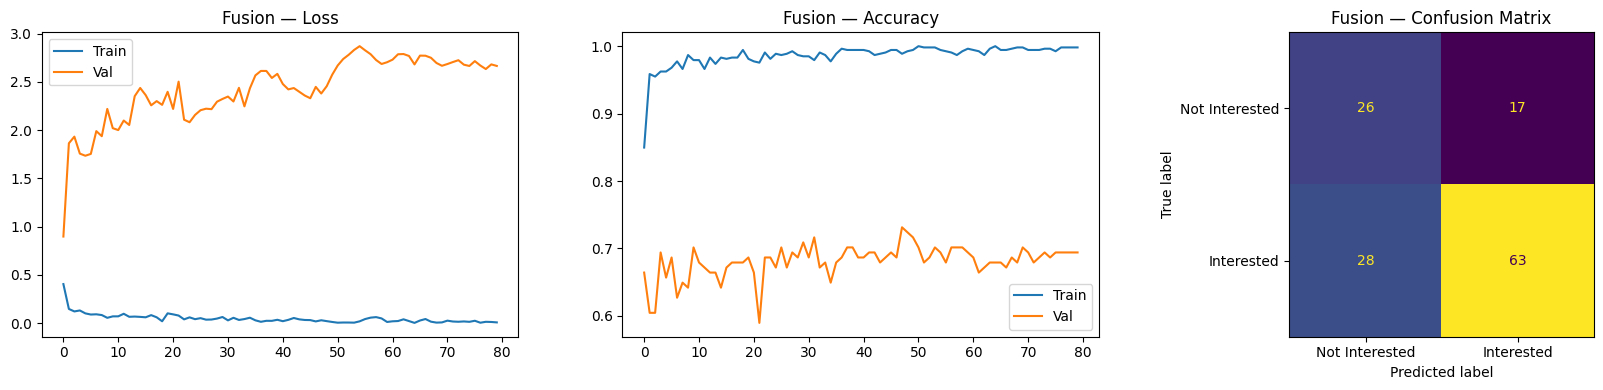

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
 
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Fusion — Loss"); axes[0].legend()
 
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Fusion — Accuracy"); axes[1].legend()
 
cm = confusion_matrix(fuse_labels, fuse_preds)
ConfusionMatrixDisplay(
    cm, display_labels=["Not Interested", "Interested"]
).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Fusion — Confusion Matrix")
 
plt.tight_layout()
plt.savefig("fusion_results.png", dpi=120)
plt.show()

In [33]:
import joblib
 
torch.save(best_fuse_state,      "fusion_model.pt")
torch.save(best_demo_state,      "tabtransformer.pt")
torch.save(best_vid_state,       "video_mlp.pt")
joblib.dump(demo_scaler,         "demo_scaler.pkl")
joblib.dump(video_scaler,        "video_scaler.pkl")
joblib.dump(FEATURE_COLS,        "feature_cols.pkl")
 
print("Saved:")
print("  fusion_model.pt      ← full fusion model")
print("  tabtransformer.pt    ← demographic branch")
print("  video_mlp.pt         ← video branch")
print("  demo_scaler.pkl")
print("  video_scaler.pkl")
print("  feature_cols.pkl")

Saved:
  fusion_model.pt      ← full fusion model
  tabtransformer.pt    ← demographic branch
  video_mlp.pt         ← video branch
  demo_scaler.pkl
  video_scaler.pkl
  feature_cols.pkl


In [34]:
# ============================================================
# CELL 19 — Individual branch final evaluation
# ============================================================

# ── Demographic branch ──────────────────────────────────────
demo_model.eval()
demo_preds, demo_probs, demo_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader_demo:
        logits = demo_model(xb.to(DEVICE))
        probs  = F.softmax(logits, dim=1)[:, 1]
        demo_preds.extend(logits.argmax(1).cpu().numpy())
        demo_probs.extend(probs.cpu().numpy())
        demo_labels.extend(yb.numpy())

print("=" * 55)
print("DEMOGRAPHIC BRANCH (TabTransformer)")
print("=" * 55)
print(classification_report(demo_labels, demo_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(demo_labels, demo_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(demo_labels, demo_probs):.4f}")

# ── Video branch ────────────────────────────────────────────
video_model.eval()
vid_preds, vid_probs, vid_labels = [], [], []
with torch.no_grad():
    for xb, yb in test_loader_vid:
        logits = video_model(xb.to(DEVICE))
        probs  = F.softmax(logits, dim=1)[:, 1]
        vid_preds.extend(logits.argmax(1).cpu().numpy())
        vid_probs.extend(probs.cpu().numpy())
        vid_labels.extend(yb.numpy())

print("\n" + "=" * 55)
print("VIDEO BRANCH (MobileNetV2 + MLP)")
print("=" * 55)
print(classification_report(vid_labels, vid_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(vid_labels, vid_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(vid_labels, vid_probs):.4f}")

# ── Fusion branch ────────────────────────────────────────────
print("\n" + "=" * 55)
print("FUSION (FusionTransformer)")
print("=" * 55)
print(classification_report(fuse_labels, fuse_preds,
      target_names=["Not Interested", "Interested"]))
print(f"Accuracy : {accuracy_score(fuse_labels, fuse_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(fuse_labels, fuse_probs):.4f}")

# ── Summary table ────────────────────────────────────────────
print("\n" + "=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"{'Model':<30} {'Accuracy':>10} {'AUC':>10}")
print("-" * 55)
print(f"{'TabTransformer (Demo)':<30} "
      f"{accuracy_score(demo_labels, demo_preds):>10.4f} "
      f"{roc_auc_score(demo_labels, demo_probs):>10.4f}")
print(f"{'MobileNetV2 + MLP (Video)':<30} "
      f"{accuracy_score(vid_labels, vid_preds):>10.4f} "
      f"{roc_auc_score(vid_labels, vid_probs):>10.4f}")
print(f"{'FusionTransformer':<30} "
      f"{accuracy_score(fuse_labels, fuse_preds):>10.4f} "
      f"{roc_auc_score(fuse_labels, fuse_probs):>10.4f}")

DEMOGRAPHIC BRANCH (TabTransformer)
                precision    recall  f1-score   support

Not Interested       0.61      0.79      0.69        43
    Interested       0.88      0.76      0.82        91

      accuracy                           0.77       134
     macro avg       0.75      0.77      0.75       134
  weighted avg       0.80      0.77      0.77       134

Accuracy : 0.7687
ROC-AUC  : 0.8293

VIDEO BRANCH (MobileNetV2 + MLP)
                precision    recall  f1-score   support

Not Interested       0.44      0.49      0.46        43
    Interested       0.74      0.70      0.72        91

      accuracy                           0.63       134
     macro avg       0.59      0.60      0.59       134
  weighted avg       0.65      0.63      0.64       134

Accuracy : 0.6343
ROC-AUC  : 0.5903

FUSION (FusionTransformer)
                precision    recall  f1-score   support

Not Interested       0.48      0.60      0.54        43
    Interested       0.79      0.69    

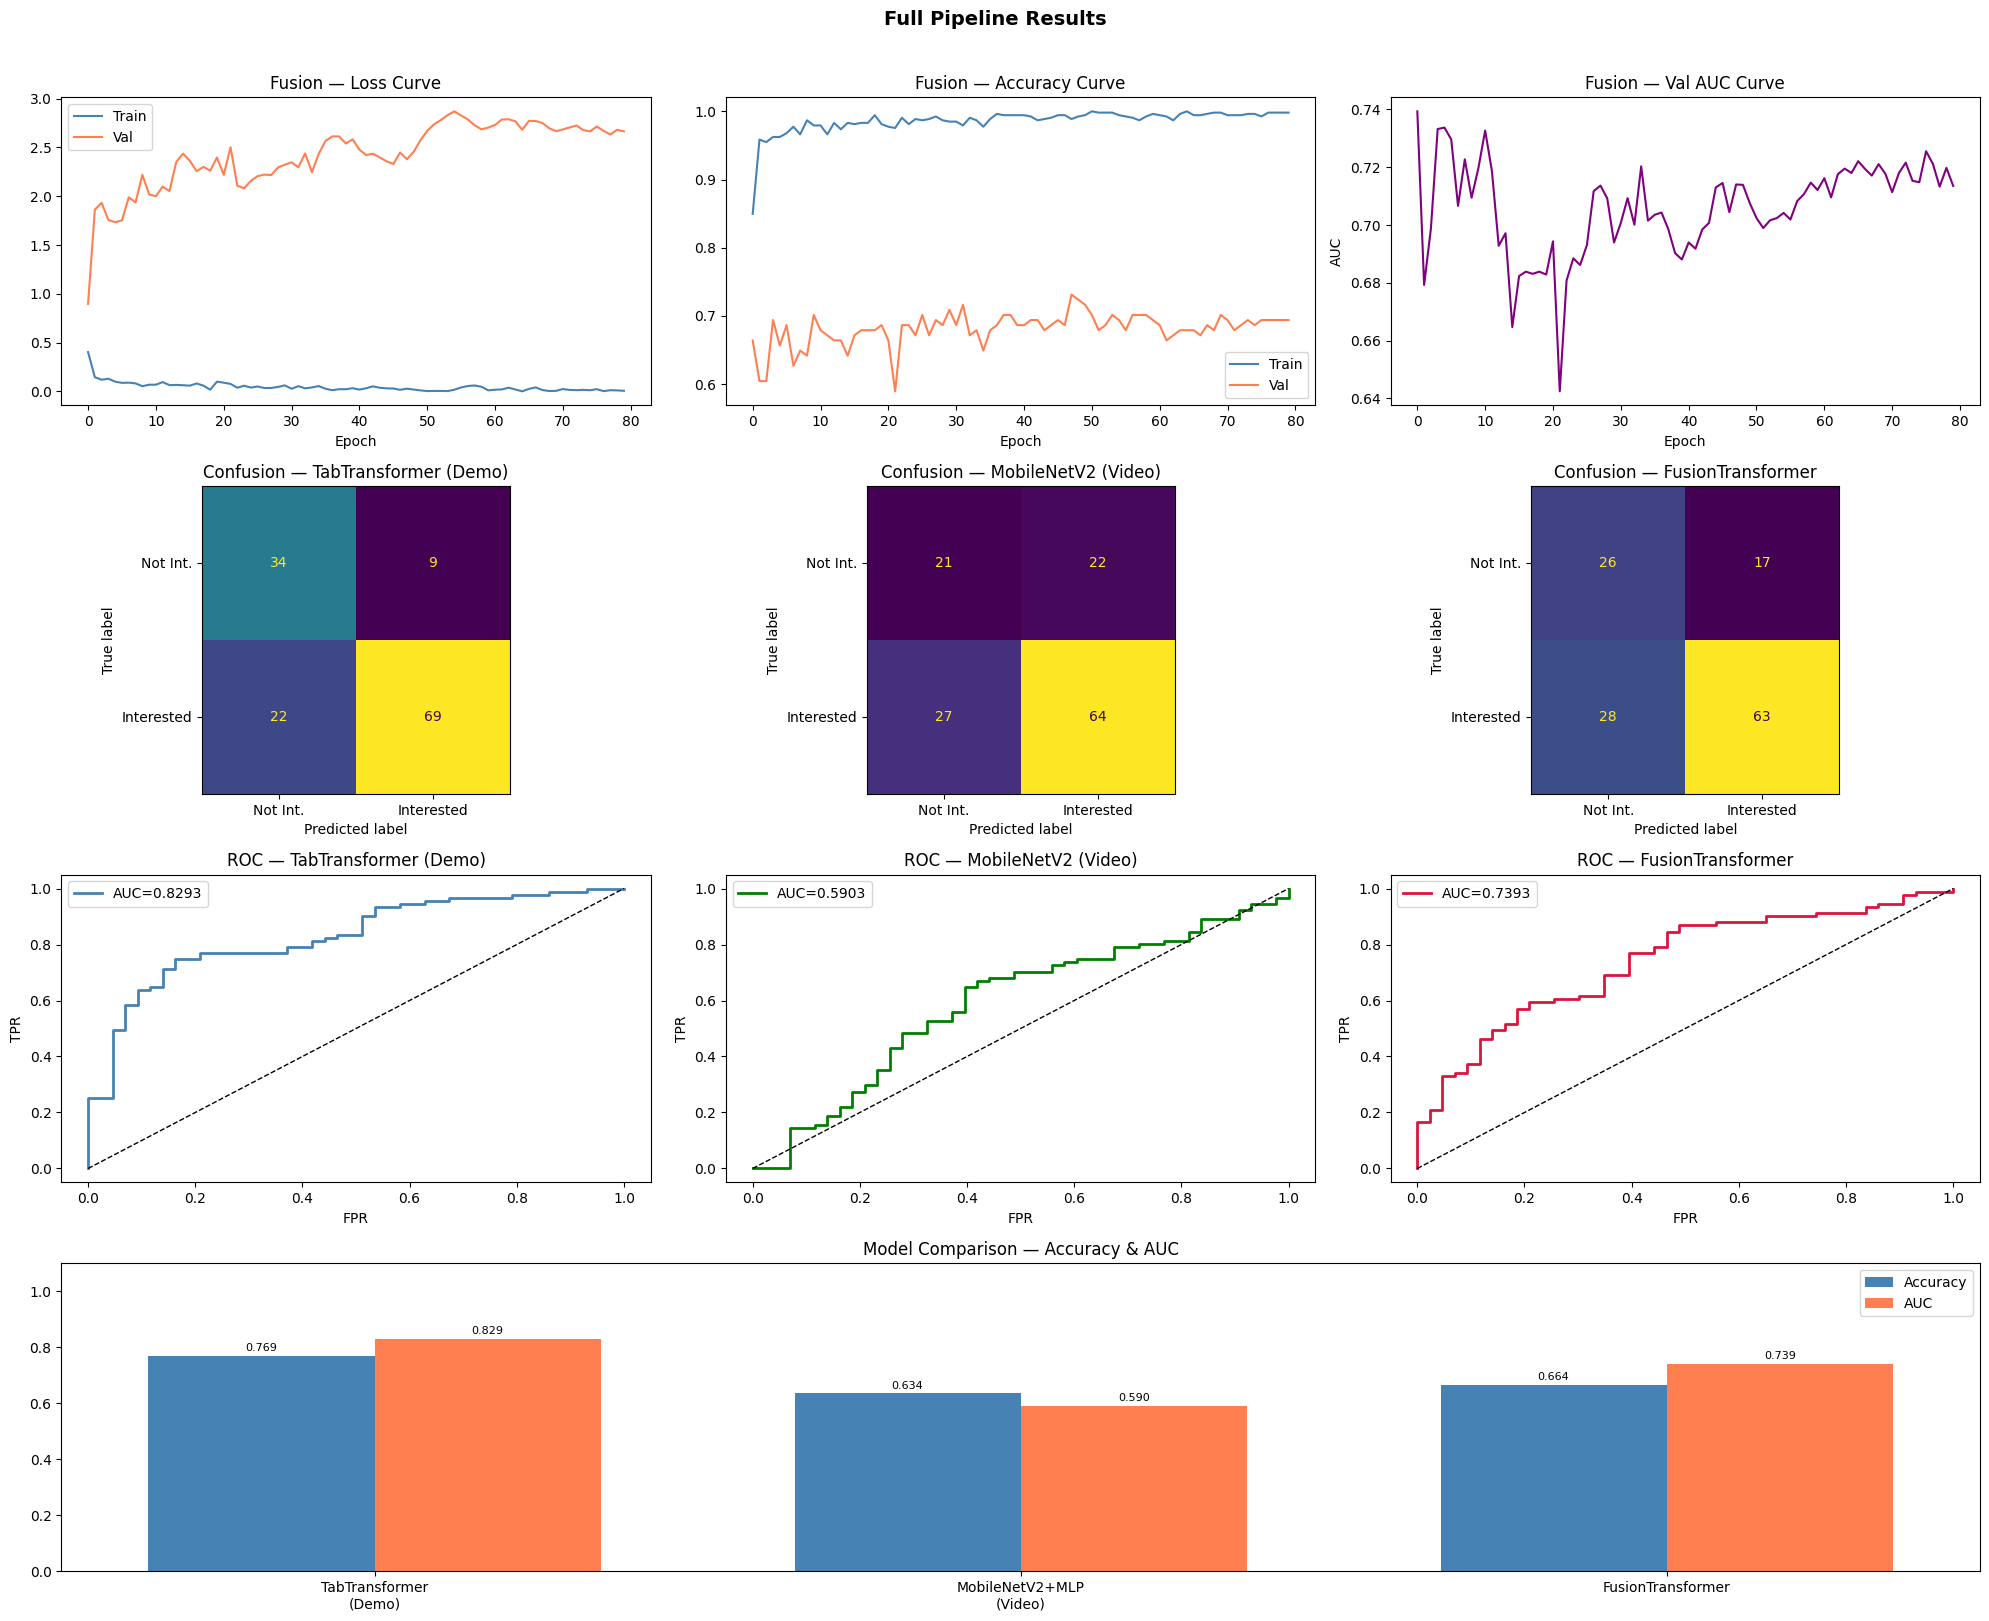

Saved → all_results.png


In [35]:
# ============================================================
# CELL 20 — All graphs (Loss, Accuracy, Confusion Matrix,
#            ROC Curve for all three models)
# ============================================================

fig = plt.figure(figsize=(20, 16))

# ── Row 1: Training curves (fusion only — branches don't
#    store per-epoch history, just final results) ────────────
ax1 = fig.add_subplot(4, 3, 1)
ax1.plot(history["train_loss"], label="Train", color="steelblue")
ax1.plot(history["val_loss"],   label="Val",   color="coral")
ax1.set_title("Fusion — Loss Curve")
ax1.set_xlabel("Epoch"); ax1.legend()

ax2 = fig.add_subplot(4, 3, 2)
ax2.plot(history["train_acc"], label="Train", color="steelblue")
ax2.plot(history["val_acc"],   label="Val",   color="coral")
ax2.set_title("Fusion — Accuracy Curve")
ax2.set_xlabel("Epoch"); ax2.legend()

ax3 = fig.add_subplot(4, 3, 3)
ax3.plot(history["val_auc"], color="purple")
ax3.set_title("Fusion — Val AUC Curve")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("AUC")

# ── Row 2: Confusion matrices ───────────────────────────────
for idx, (labels, preds, title) in enumerate([
    (demo_labels,  demo_preds,  "TabTransformer (Demo)"),
    (vid_labels,   vid_preds,   "MobileNetV2 (Video)"),
    (fuse_labels,  fuse_preds,  "FusionTransformer"),
]):
    ax = fig.add_subplot(4, 3, 4 + idx)
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(
        cm, display_labels=["Not Int.", "Interested"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion — {title}")

# ── Row 3: ROC curves ───────────────────────────────────────
from sklearn.metrics import roc_curve

ax_roc1 = fig.add_subplot(4, 3, 7)
ax_roc2 = fig.add_subplot(4, 3, 8)
ax_roc3 = fig.add_subplot(4, 3, 9)

for ax_r, labels, probs, title, color in [
    (ax_roc1, demo_labels,  demo_probs,  "TabTransformer (Demo)",  "steelblue"),
    (ax_roc2, vid_labels,   vid_probs,   "MobileNetV2 (Video)",    "green"),
    (ax_roc3, fuse_labels,  fuse_probs,  "FusionTransformer",      "crimson"),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val     = roc_auc_score(labels, probs)
    ax_r.plot(fpr, tpr, color=color,
              label=f"AUC={auc_val:.4f}", linewidth=2)
    ax_r.plot([0,1],[0,1],"k--", linewidth=1)
    ax_r.set_title(f"ROC — {title}")
    ax_r.set_xlabel("FPR"); ax_r.set_ylabel("TPR")
    ax_r.legend()

# ── Row 4: Bar chart comparison ─────────────────────────────
ax_bar = fig.add_subplot(4, 3, (10, 12))
models_names = [
    "TabTransformer\n(Demo)",
    "MobileNetV2+MLP\n(Video)",
    "FusionTransformer"
]
accs = [
    accuracy_score(demo_labels,  demo_preds),
    accuracy_score(vid_labels,   vid_preds),
    accuracy_score(fuse_labels,  fuse_preds),
]
aucs = [
    roc_auc_score(demo_labels,  demo_probs),
    roc_auc_score(vid_labels,   vid_probs),
    roc_auc_score(fuse_labels,  fuse_probs),
]
x    = np.arange(len(models_names))
w    = 0.35
bars1 = ax_bar.bar(x - w/2, accs, w, label="Accuracy", color="steelblue")
bars2 = ax_bar.bar(x + w/2, aucs, w, label="AUC",      color="coral")
ax_bar.set_xticks(x); ax_bar.set_xticklabels(models_names)
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title("Model Comparison — Accuracy & AUC")
ax_bar.legend()
for bar in bars1 + bars2:
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=8
    )

plt.suptitle("Full Pipeline Results", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("all_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → all_results.png")